# Carregando noticias coletadas

In [1]:
import pickle
from pathlib import Path

In [2]:
NEWS_DIR = "/exp_local/kenzosaki/data/iptc/raw_news"

# Carregando todos os arquivos coletados

In [3]:
news = []
for file in Path(NEWS_DIR).rglob("*.pkl"):
    print(f"Loading {file}...")
    news += pickle.load(open(file, "rb"))

Loading /exp_local/kenzosaki/data/iptc/raw_news/cybersecurity/cybersecurity data breach digital attack.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/science/science technology innovation.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/weather/weather storm flood drought.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/economy/economy business finance crisis.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/environment/environment climate pollution.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/society/society migration refugees community.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/politics/politics government election crisis.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/crime/crime law justice investigation.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/education/education school university policy.pkl...
Loading /exp_local/kenzosaki/data/iptc/raw_news/transport/transport accident infrastructure.pkl...
Loading /exp_local/ken

In [4]:
len(news)

135232

# Transformando os dados em um DataFrame

In [5]:
import pandas as pd

In [6]:
news_df = pd.DataFrame(news)

In [7]:
news_df.head()

,title,description,published date,url,publisher,query
0,No Longer Invisible: When Cyber Attacks Go Phy...,No Longer Invisible: When Cyber Attacks Go Phy...,"Sun, 31 May 2026 09:05:49 GMT",https://news.google.com/rss/articles/CBMiqgFBV...,"{'href': 'https://www.govtech.com', 'title': '...",cybersecurity data breach digital attack
1,Cybersecurity considerations 2026 - KPMG,Cybersecurity considerations 2026 KPMG,"Mon, 01 Jun 2026 00:07:16 GMT",https://news.google.com/rss/articles/CBMihAFBV...,"{'href': 'https://kpmg.com', 'title': 'KPMG'}",cybersecurity data breach digital attack
2,Cybersecurity vs Data Science: Flourishing Car...,Cybersecurity vs Data Science: Flourishing Car...,"Mon, 01 Jun 2026 05:40:36 GMT",https://news.google.com/rss/articles/CBMirAFBV...,{'href': 'https://www.cybersecurity-insiders.c...,cybersecurity data breach digital attack
3,EY Agentic SOC: AI-driven cybersecurity and se...,EY Agentic SOC: AI-driven cybersecurity and se...,"Sun, 31 May 2026 15:44:22 GMT",https://news.google.com/rss/articles/CBMiswFBV...,"{'href': 'https://www.ey.com', 'title': 'EY'}",cybersecurity data breach digital attack
4,Logistics giant suffers massive 840-million-re...,Logistics giant suffers massive 840-million-re...,"Mon, 01 Jun 2026 05:10:01 GMT",https://news.google.com/rss/articles/CBMitAFBV...,"{'href': 'https://www.escudodigital.com', 'tit...",cybersecurity data breach digital attack


In [8]:
# aparentemente sem dados nulos
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 135232 entries, 0 to 135231
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   title           135232 non-null  str   
 1   description     135232 non-null  str   
 2   published date  135232 non-null  str   
 3   url             135232 non-null  str   
 4   publisher       135232 non-null  object
 5   query           135232 non-null  str   
dtypes: object(1), str(5)
memory usage: 78.9+ MB


# Número de eventos por tópico

In [9]:
news_df.groupby("query").size()

query
conflict war peace attack                    7471
crime law justice investigation             10064
cybersecurity data breach digital attack    10034
disaster accident emergency incident         8710
economy business finance crisis             10087
education school university policy          10075
energy power outage fuel                    10028
environment climate pollution               10074
health disease outbreak hospital            10043
labour strike employment union              10103
politics government election crisis         10021
science technology innovation               10035
society migration refugees community         4968
transport accident infrastructure            5349
weather storm flood drought                  8170
dtype: int64

<Axes: ylabel='query'>

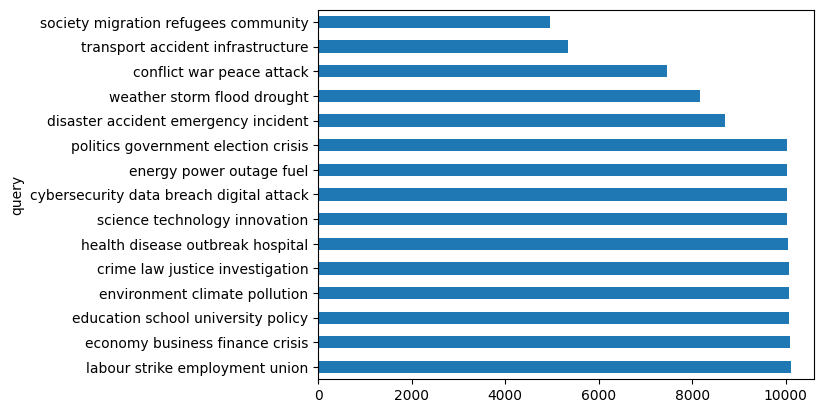

In [10]:
news_df.groupby("query").size().sort_values(ascending=False).plot.barh()

# Determinando datas mínimas e máximas

In [11]:
news_df["published date"] = pd.to_datetime(news_df["published date"], format='mixed')

In [12]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 135232 entries, 0 to 135231
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   title           135232 non-null  str                
 1   description     135232 non-null  str                
 2   published date  135232 non-null  datetime64[us, UTC]
 3   url             135232 non-null  str                
 4   publisher       135232 non-null  object             
 5   query           135232 non-null  str                
dtypes: datetime64[us, UTC](1), object(1), str(4)
memory usage: 75.2+ MB


In [13]:
min_dates = news_df.groupby("query")["published date"].min()
max_dates = news_df.groupby("query")["published date"].max()

In [14]:
min_max_date_df = pd.DataFrame({"min_date": min_dates, "max_date": max_dates})

In [15]:
min_max_date_df

,min_date,max_date
query,,
conflict war peace attack,2016-06-16 07:00:00+00:00,2026-06-01 07:00:00+00:00
crime law justice investigation,2020-07-23 07:00:00+00:00,2026-06-01 06:46:42+00:00
cybersecurity data breach digital attack,2020-05-04 07:00:00+00:00,2026-06-01 06:47:28+00:00
disaster accident emergency incident,2016-06-14 07:00:00+00:00,2026-06-01 05:00:00+00:00
economy business finance crisis,2021-01-19 08:00:00+00:00,2026-06-01 06:38:09+00:00
education school university policy,2020-10-31 07:00:00+00:00,2026-06-01 07:00:00+00:00
energy power outage fuel,2021-03-20 07:00:00+00:00,2026-06-01 07:00:00+00:00
environment climate pollution,2021-02-08 08:00:00+00:00,2026-06-01 07:00:00+00:00
health disease outbreak hospital,2020-02-14 08:00:00+00:00,2026-06-01 07:00:00+00:00


<Axes: xlabel='published date'>

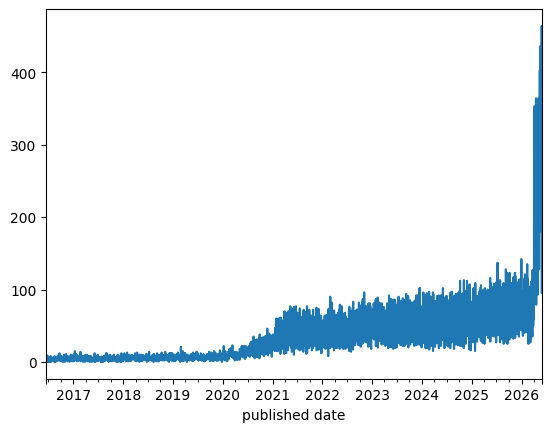

In [16]:
# quantidade de noticias por dia. a maioria é de 2026
# aparentemente o gnews reduz a taxa de noticias recuperadas apos algumas consultas e isso é reportado por outros usuários.
# talvez seja devido a taxa de consultas por usuário
date_df = news_df.set_index("published date")
date_df.resample("D").size().plot()

<Axes: xlabel='published date'>

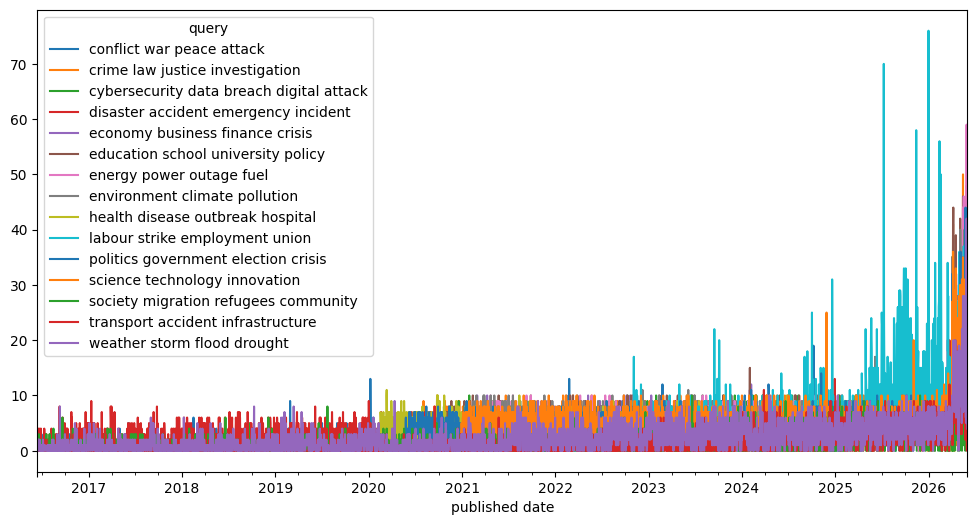

In [17]:
# quantidade de noticias por dia e por query
date_query_df = news_df.set_index("published date").groupby("query").resample("D").size().unstack(level=0).fillna(0)
date_query_df.plot(figsize=(12, 6))

<Axes: xlabel='published date'>

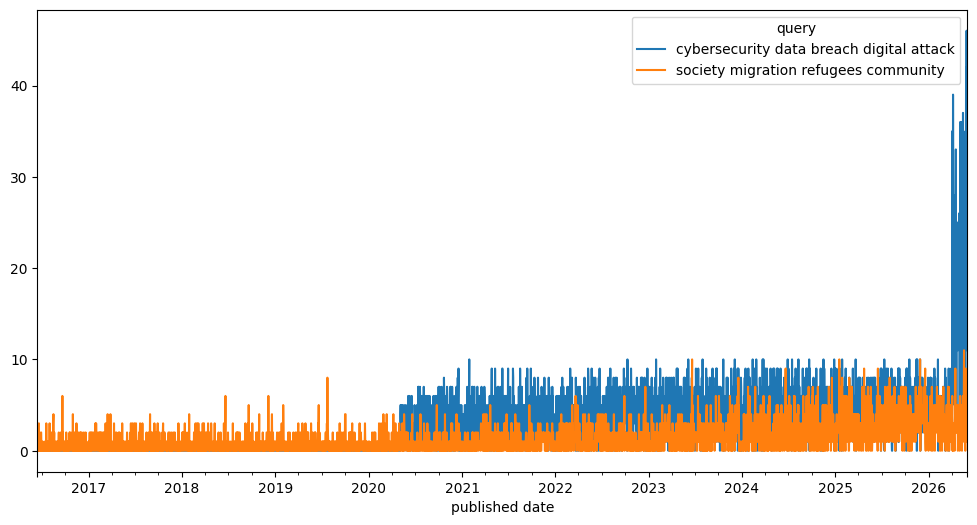

In [22]:
# filtrando dois temas em esp
society_mask = news_df["query"].str.contains("society")
cybersecurity_mask = news_df["query"].str.contains("cybersecurity")
filtered_news_df = news_df[society_mask | cybersecurity_mask]

date_query_df = filtered_news_df.set_index("published date").groupby("query").resample("D").size().unstack(level=0).fillna(0)
date_query_df.plot(figsize=(12, 6))

# Visualizando alguns exemplos

In [19]:
# increassing pandas col width
pd.set_option("display.max_colwidth", None)

In [20]:
queries = news_df["query"].unique()
queries

<ArrowStringArray>
['cybersecurity data breach digital attack',
            'science technology innovation',
              'weather storm flood drought',
          'economy business finance crisis',
            'environment climate pollution',
     'society migration refugees community',
      'politics government election crisis',
          'crime law justice investigation',
       'education school university policy',
        'transport accident infrastructure',
                'conflict war peace attack',
           'labour strike employment union',
     'disaster accident emergency incident',
                 'energy power outage fuel',
         'health disease outbreak hospital']
Length: 15, dtype: str

In [21]:
news_df[news_df["query"] == queries[14]].sample(10)[["title", "published date", "query"]]

,title,published date,query
125403,Ebola case confirmed in rebel-held Congo area far from outbreak's epicentre - Reuters,2026-05-21 07:00:00+00:00,health disease outbreak hospital
126224,"Vietnam: Sharp increase in hand, foot, and mouth disease hospitalizations - Outbreak News Today",2026-03-21 07:00:00+00:00,health disease outbreak hospital
126194,Are UK students at risk of more deadly meningitis outbreaks? - BBC,2026-03-28 07:00:00+00:00,health disease outbreak hospital
128339,Epidemic and emerging disease alerts in the Pacific as of 10 December 2024 - ReliefWeb,2024-12-10 08:00:00+00:00,health disease outbreak hospital
126668,"Doctor strike during flu outbreak would be 'reckless', says Starmer - BBC",2025-12-12 08:00:00+00:00,health disease outbreak hospital
132587,COVIDSAVIOR: A Novel Sensor-Fusion and Deep Learning Based Framework for Virus Outbreaks - Frontiers,2021-11-29 08:00:00+00:00,health disease outbreak hospital
126069,AIIMS Delhi Head of Nephrology Dr Dipankar Bhowmik urges hospitals to scale CKD screening and green dialysis - healthcareexecutive.in,2026-04-09 07:00:00+00:00,health disease outbreak hospital
129367,Measles: South Wales outbreak declared amid two new cases - BBC,2024-04-09 07:00:00+00:00,health disease outbreak hospital
128448,How Climate Change Affects Our Health - CFR Education,2024-11-13 08:00:00+00:00,health disease outbreak hospital
132064,Modeling transmission of SARS-CoV-2 Omicron in China - Nature,2022-05-10 07:00:00+00:00,health disease outbreak hospital
